# Dataset Analysis & Visualization
Analyze the RF control dataset to understand feature-target relationships, class separability, and feasibility of the ML tasks (classification & regression) using the shared latent space.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/optimal_control_dataset.csv")

# Derived targets matching the model
df["LNA_Class"] = (df["Optimal_LNA_Voltage_V"] > 4.0).astype(int)  # 0=3V, 1=5V
df["LNA_Label"] = df["LNA_Class"].map({0: "3V", 1: "5V"})

print(f"Samples: {len(df)}")
df.describe()

Samples: 300


,Input_Power_dBm,Bandwidth_Hz,Optimal_LNA_Voltage_V,Optimal_IF_Gain_dB,Optimal_LO_Power_dBm,Best_EVM_dB,Resulting_NF_dB,Resulting_S11_dB,Measured_Power_Post_LNA_dBm,Measured_Power_Post_PA_dBm,LNA_Class
count,300.000000,3.000000e+02,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,-40.000000,1.033333e+07,4.013333,11.790443,5.304113,10.564099,1.008218,-13.495899,-31.759765,-42.952915,0.506667
std,11.682546,7.773264e+06,1.001582,10.542937,10.627535,3.474614,0.017132,0.412605,9.674409,22.280006,0.500791
min,-60.000000,1.000000e+06,3.000000,-5.768278,-13.516037,4.732478,0.990885,-13.902360,-50.429818,-74.046398,0.000000
25%,-50.000000,1.000000e+06,3.000000,2.415707,-4.921525,6.805681,0.990885,-13.902360,-39.544748,-61.479636,0.000000
50%,-40.000000,1.000000e+07,5.000000,11.953026,6.016920,10.501059,1.025095,-13.902360,-33.160996,-48.185955,1.000000
75%,-30.000000,2.000000e+07,5.000000,22.655038,16.032711,13.345570,1.025095,-13.078453,-23.568218,-28.126892,1.000000
max,-20.000000,2.000000e+07,5.000000,25.991043,19.908859,29.358070,1.025095,-13.078453,-13.502057,4.051792,1.000000


In [ ]:
## 1. Target Distributions
Check class balance for classification outputs (LNA, Filter) and regression target distributions (IF Gain, Mixer/LO Power).

**Network outputs:** LNA Voltage (classification), IF Gain (regression), Mixer Power (regression), Filter (symbolic), Mixer Frequency (symbolic)

   Input_Power_dBm  Bandwidth_Hz  Optimal_LNA_Voltage_V  Optimal_IF_Gain_dB  \
0       -60.000000     1000000.0                    3.0           23.253542   
1       -59.595960     1000000.0                    5.0           22.421488   
2       -59.191919     1000000.0                    5.0           19.743771   
3       -58.787879     1000000.0                    3.0           22.626409   
4       -58.383838     1000000.0                    3.0           -5.732422   

   Optimal_LO_Power_dBm  Best_EVM_dB  Resulting_NF_dB  Resulting_S11_dB  \
0             19.719830     5.819126         0.990885        -13.078453   
1              8.642827     7.367656         1.025095        -13.902360   
2            -10.749573     7.726203         1.025095        -13.902360   
3             10.505211     6.185128         0.990885        -13.078453   
4              3.516209     7.454745         0.990885        -13.078453   

   Measured_Power_Post_LNA_dBm  Measured_Power_Post_PA_dBm Detected_BW_Cla

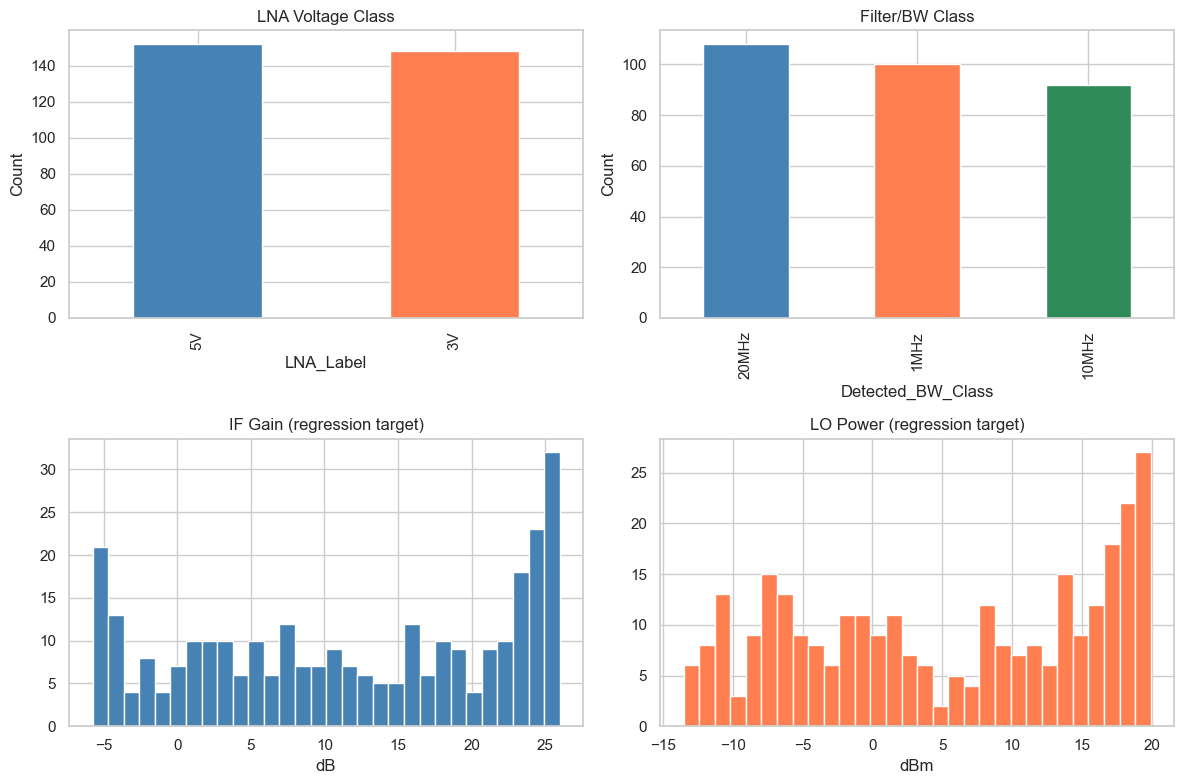

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# LNA class distribution
df["LNA_Label"].value_counts().plot.bar(ax=axes[0, 0], color=["steelblue", "coral"])
axes[0, 0].set_title("LNA Voltage Class")
axes[0, 0].set_ylabel("Count")

# Filter class distribution
df["Detected_BW_Class"].value_counts().plot.bar(ax=axes[0, 1], color=["steelblue", "coral", "seagreen"])
axes[0, 1].set_title("Filter/BW Class")
axes[0, 1].set_ylabel("Count")

# IF Gain distribution
axes[1, 0].hist(df["Optimal_IF_Gain_dB"], bins=30, color="steelblue", edgecolor="white")
axes[1, 0].set_title("IF Gain (regression target)")
axes[1, 0].set_xlabel("dB")

# LO Power distribution
axes[1, 1].hist(df["Optimal_LO_Power_dBm"], bins=30, color="coral", edgecolor="white")
axes[1, 1].set_title("LO Power (regression target)")
axes[1, 1].set_xlabel("dBm")

plt.tight_layout()
plt.show()

## 2. Correlation Heatmap
Correlations between the 3 **tabular network inputs** (EVM, Post-LNA power, Post-PA power) and the 4 **tabular network outputs** (LNA class, Filter class, IF Gain, Mixer/LO Power).

Note: STFT input and Mixer Frequency output are not scalar columns — they can't appear here.

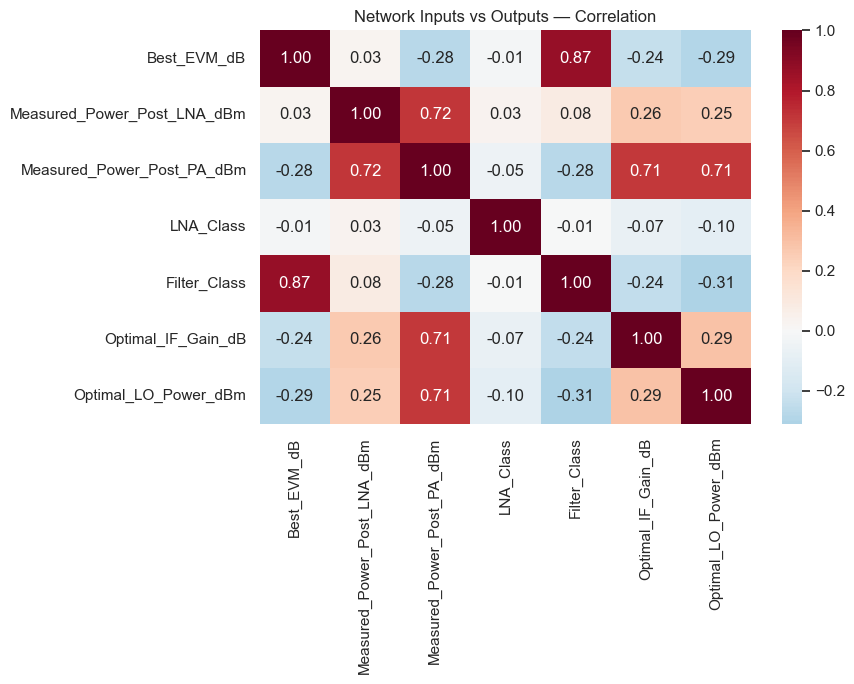

In [12]:
# Map filter class to numeric for correlation
df["Filter_Class"] = df["Detected_BW_Class"].map({"1MHz": 0, "10MHz": 1, "20MHz": 2})

# Network inputs (tabular only — STFT is the 4th input but not scalar)
input_cols = ["Best_EVM_dB", "Measured_Power_Post_LNA_dBm", "Measured_Power_Post_PA_dBm"]
# Network outputs (mixer frequency is symbolic from STFT, not in CSV)
output_cols = ["LNA_Class", "Filter_Class", "Optimal_IF_Gain_dB", "Optimal_LO_Power_dBm"]

corr_cols = input_cols + output_cols
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Network Inputs vs Outputs — Correlation")
plt.tight_layout()
plt.show()

## 3. Tabular Inputs vs Regression Outputs
Scatter plots of the 3 tabular network inputs against the 2 regression outputs (IF Gain, Mixer/LO Power).

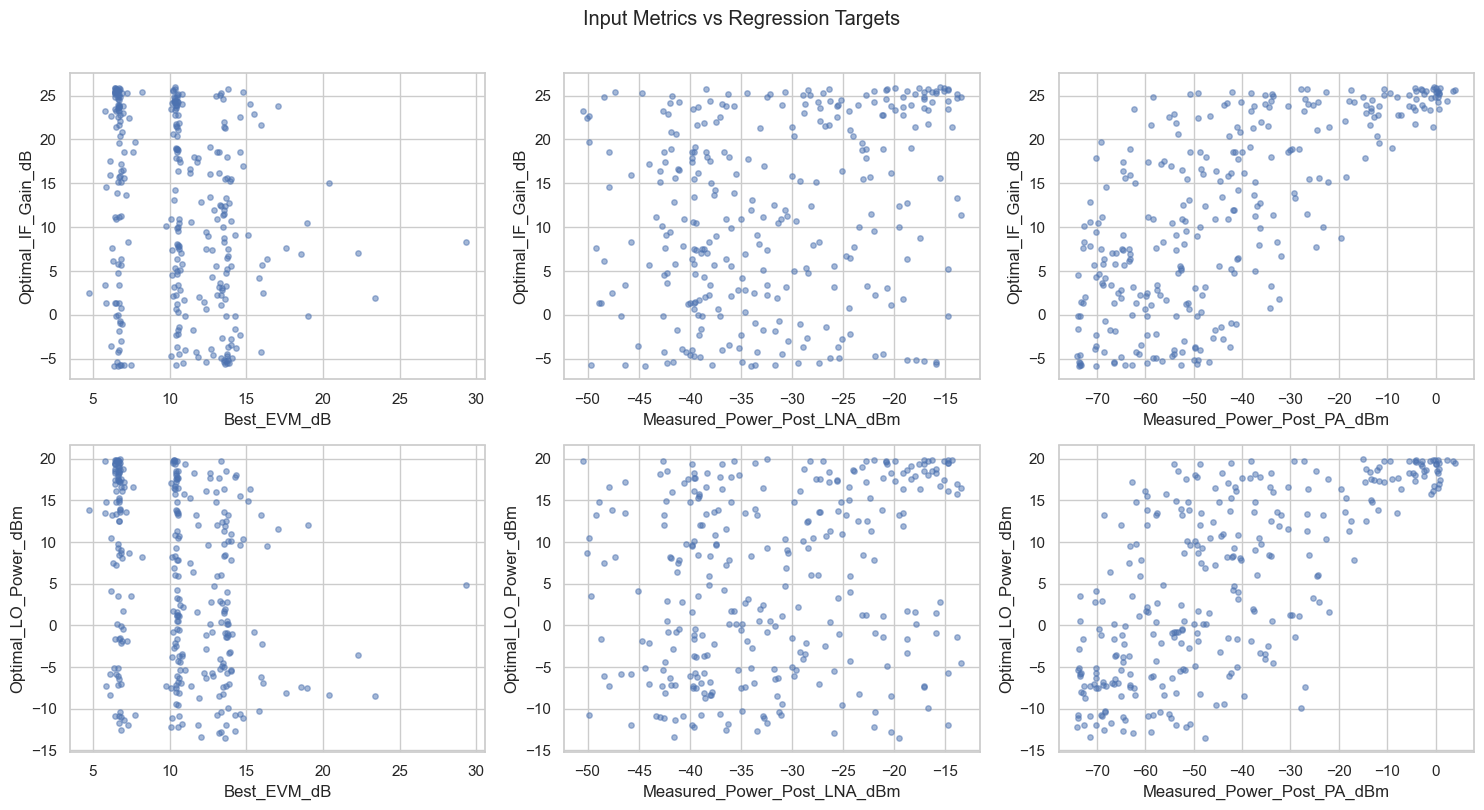

In [13]:
input_metrics = ["Best_EVM_dB", "Measured_Power_Post_LNA_dBm", "Measured_Power_Post_PA_dBm"]
reg_targets = ["Optimal_IF_Gain_dB", "Optimal_LO_Power_dBm"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, target in enumerate(reg_targets):
    for i, metric in enumerate(input_metrics):
        axes[j, i].scatter(df[metric], df[target], alpha=0.5, s=15)
        axes[j, i].set_xlabel(metric)
        axes[j, i].set_ylabel(target)
plt.suptitle("Input Metrics vs Regression Targets", y=1.01)
plt.tight_layout()
plt.show()

## 4. PCA of Tabular Inputs — Colored by Each Output
PCA on the 3 tabular network inputs (EVM, Post-LNA, Post-PA) projected to 2D, colored by each output target. This shows whether the tabular input space alone can separate the different tasks.

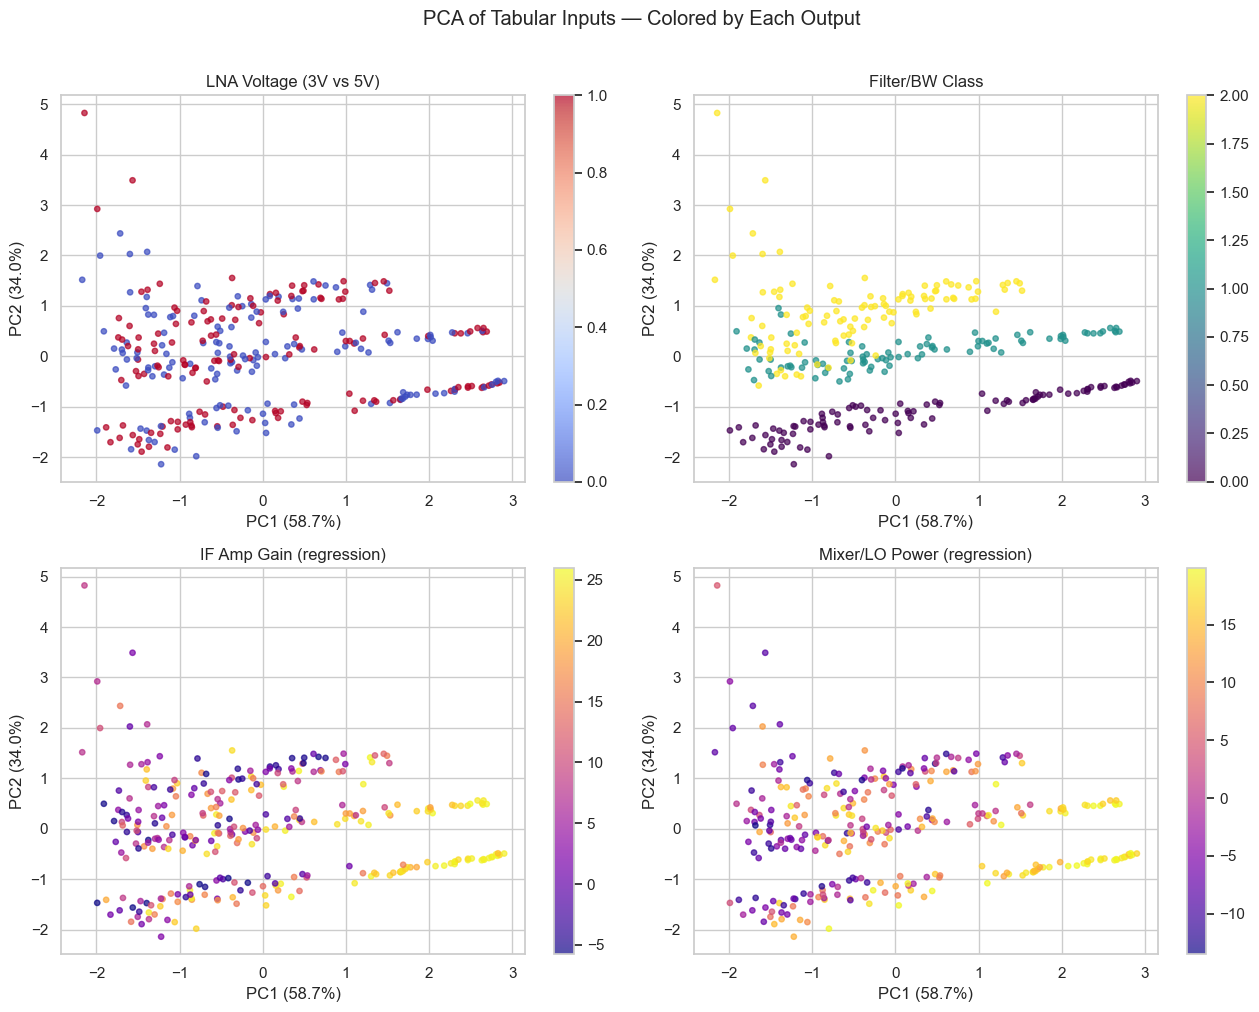

PCA explained variance: PC1=58.7%, PC2=34.0%, total=92.6%
(Note: only 3 tabular features projected to 2D — STFT input is not included here)


In [14]:
# Only the 3 tabular inputs that go into the MLP branch of the backbone
feature_cols = ["Best_EVM_dB", "Measured_Power_Post_LNA_dBm", "Measured_Power_Post_PA_dBm"]

X = StandardScaler().fit_transform(df[feature_cols])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
var = pca.explained_variance_ratio_

# LNA class
scatter = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=df["LNA_Class"], cmap="coolwarm", s=15, alpha=0.7)
axes[0, 0].set_title("LNA Voltage (3V vs 5V)")
plt.colorbar(scatter, ax=axes[0, 0])

# Filter class
scatter = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=df["Filter_Class"], cmap="viridis", s=15, alpha=0.7)
axes[0, 1].set_title("Filter/BW Class")
plt.colorbar(scatter, ax=axes[0, 1])

# IF Gain (regression)
scatter = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=df["Optimal_IF_Gain_dB"], cmap="plasma", s=15, alpha=0.7)
axes[1, 0].set_title("IF Amp Gain (regression)")
plt.colorbar(scatter, ax=axes[1, 0])

# Mixer/LO Power (regression)
scatter = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=df["Optimal_LO_Power_dBm"], cmap="plasma", s=15, alpha=0.7)
axes[1, 1].set_title("Mixer/LO Power (regression)")
plt.colorbar(scatter, ax=axes[1, 1])

for ax in axes.flat:
    ax.set_xlabel(f"PC1 ({var[0]:.1%})")
    ax.set_ylabel(f"PC2 ({var[1]:.1%})")

plt.suptitle("PCA of Tabular Inputs — Colored by Each Output", y=1.01)
plt.tight_layout()
plt.show()

print(f"PCA explained variance: PC1={var[0]:.1%}, PC2={var[1]:.1%}, total={sum(var):.1%}")
print(f"(Note: only 3 tabular features projected to 2D — STFT input is not included here)")

## 5. t-SNE of Tabular Inputs — Classification Outputs
t-SNE on the same 3 tabular inputs to reveal non-linear clusters for the two classification outputs (LNA, Filter).

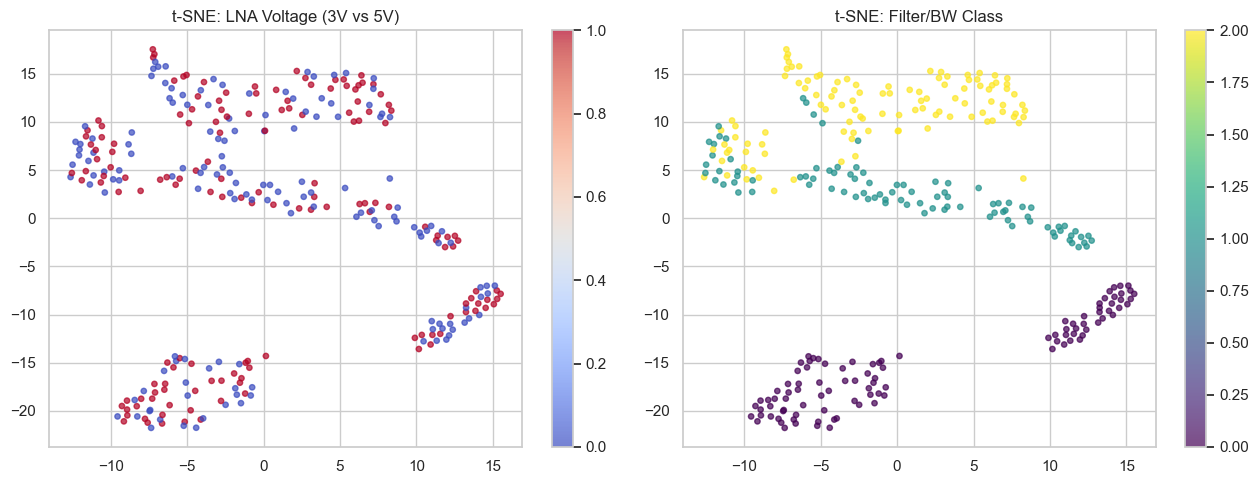

In [15]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=df["LNA_Class"], cmap="coolwarm", s=15, alpha=0.7)
axes[0].set_title("t-SNE: LNA Voltage (3V vs 5V)")
plt.colorbar(scatter, ax=axes[0])

scatter = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=df["Filter_Class"], cmap="viridis", s=15, alpha=0.7)
axes[1].set_title("t-SNE: Filter/BW Class")
plt.colorbar(scatter, ax=axes[1])

plt.tight_layout()
plt.show()

## 6. Regression Outputs vs Classification Outputs
Do the regression outputs (IF Gain, Mixer Power) differ across classification output groups (LNA, Filter)? Overlapping distributions indicate conflicting demands on a shared latent space.

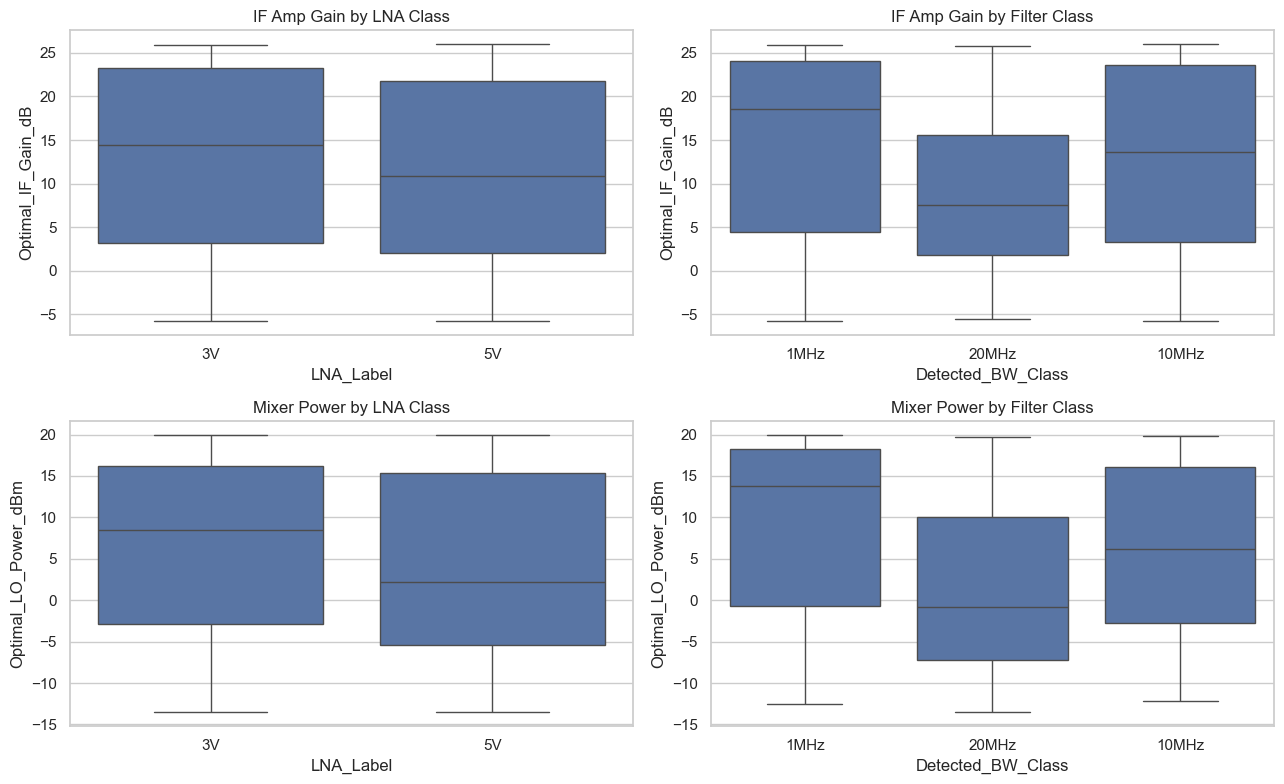

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# IF Gain by LNA class
sns.boxplot(data=df, x="LNA_Label", y="Optimal_IF_Gain_dB", ax=axes[0, 0])
axes[0, 0].set_title("IF Amp Gain by LNA Class")

# IF Gain by Filter class
sns.boxplot(data=df, x="Detected_BW_Class", y="Optimal_IF_Gain_dB", ax=axes[0, 1])
axes[0, 1].set_title("IF Amp Gain by Filter Class")

# Mixer Power by LNA class
sns.boxplot(data=df, x="LNA_Label", y="Optimal_LO_Power_dBm", ax=axes[1, 0])
axes[1, 0].set_title("Mixer Power by LNA Class")

# Mixer Power by Filter class
sns.boxplot(data=df, x="Detected_BW_Class", y="Optimal_LO_Power_dBm", ax=axes[1, 1])
axes[1, 1].set_title("Mixer Power by Filter Class")

plt.tight_layout()
plt.show()

## 7. Regression Outputs Relationship
Are IF Gain and Mixer Power correlated or orthogonal? Correlated outputs can share a latent space; independent outputs force the latent space to encode multiple signals.

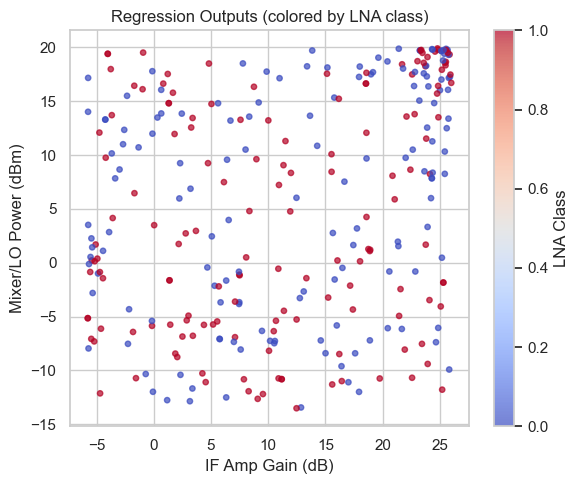

Correlation between IF Gain and Mixer Power: 0.290


In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(df["Optimal_IF_Gain_dB"], df["Optimal_LO_Power_dBm"],
                     c=df["LNA_Class"], cmap="coolwarm", s=15, alpha=0.7)
ax.set_xlabel("IF Amp Gain (dB)")
ax.set_ylabel("Mixer/LO Power (dBm)")
ax.set_title("Regression Outputs (colored by LNA class)")
plt.colorbar(scatter, ax=ax, label="LNA Class")
plt.tight_layout()
plt.show()

corr = df["Optimal_IF_Gain_dB"].corr(df["Optimal_LO_Power_dBm"])
print(f"Correlation between IF Gain and Mixer Power: {corr:.3f}")

## Key Insights

### Architecture Recap
**Inputs:** STFT (→ CNN), EVM, Post-LNA power, Post-PA power (→ MLP) — fused into shared latent space.  
**Outputs from latent space:** LNA Voltage (classification), IF Amp Gain (regression), Mixer Power (regression).  
**Symbolic outputs (from raw STFT, bypass latent space):** Filter/BW class, Mixer Frequency.

### Class Balance
- **LNA class**: Nearly perfectly balanced (~150 each). No class imbalance issues.
- **Filter/BW class**: Reasonably balanced (100/100/96). No issues.

### Regression Output Distributions
- **IF Gain**: Bimodal — clusters near the extremes (~-5 dB and ~25 dB) with a spread in between. Not a smooth distribution.
- **Mixer Power**: Roughly uniform across [-13, 20] dBm. Reasonable for regression.

### Correlation (Network Inputs → Outputs)
- **LNA Class is uncorrelated with all 3 tabular inputs** (max |r| ≈ 0.01–0.05). The 3V vs 5V decision has almost no signal in the tabular features → the CNN branch (STFT) must carry the discriminative information.
- **Filter class correlates with EVM** (r ≈ 0.87) due to the bandwidth→EVM relationship — but filter is handled symbolically so this doesn't affect the latent space.
- **IF Gain and Mixer Power both correlate with Post-PA power** (r ≈ 0.71) — Post-PA is the most informative tabular input for regression.
- **IF Gain and Mixer Power are weakly correlated with each other** (r ≈ 0.29) — largely independent regression targets.

### PCA of Tabular Inputs
- With only 3 tabular features, PCA to 2D retains most variance but captures a limited view (the STFT input is excluded).
- **Filter/BW class** shows some clustering along the EVM-dominated axis.
- **LNA class** shows **no visible separation** — completely interleaved. Tabular inputs cannot distinguish it.
- **IF Gain and Mixer Power** show partial spatial gradients, especially along the Post-PA power axis.

### t-SNE of Tabular Inputs
- **Filter/BW class**: Groups visible (driven by EVM/bandwidth correlation).
- **LNA class**: Completely mixed — **no non-linear structure** in the 3 tabular features can separate LNA classes.

### Regression vs Classification Outputs (Boxplots)
- **IF Gain and Mixer Power are identically distributed across LNA classes** — the regression and LNA classification outputs are independent.
- Mild differences by Filter class (especially IF Gain for 20 MHz), but with heavy overlap.

### Shared Latent Space Feasibility
The analysis confirms conflicting demands on the shared latent representation:

1. **LNA classification** has near-zero signal in the 3 tabular inputs. It must rely entirely on spectral features from the CNN branch. A shared latent space jointly optimized with regression (which depends on tabular features, especially Post-PA power) is likely to suppress the subtle spectral features needed for LNA.

2. **IF Gain and Mixer Power** are weakly correlated (r=0.29) but both depend on Post-PA power. A single latent vector must simultaneously encode two largely orthogonal regression signals plus a classification signal from a completely different feature source.

3. **Filter and Mixer Frequency** are symbolic (bypass the latent space), so they don't contribute to the conflict.

### Recommendations
- **Task-specific bottleneck layers** or separate latent projections per agent head
- **Larger latent dimension** to give each task enough capacity
- **Gradient balancing** (e.g., GradNorm, uncertainty weighting) to prevent regression losses from dominating